# BPMN Refine — evaluation figures

This notebook summarizes the evaluation of **BPMN Refine**. It reads stored artifacts from experiments/results and does not call an LLM.

E1 selects the model; E2–E5 select the remaining configuration; E6 evaluates detection; E7 repair; E8 refinement; and E9 repeated-call stability. The notebook recreates the seven figures used in thesis Chapter 6.

In [1]:
from collections import Counter
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from IPython.display import display


def repository_root() -> Path:
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "experiments/results").is_dir():
            return path
    raise FileNotFoundError("Run this notebook from the bpmn-refine repository.")


REPO = repository_root()
RESULTS = REPO / "experiments/results"
FIGURES = REPO.parent / "thesis/figures/ch06"
if not FIGURES.parent.parent.is_dir():
    raise FileNotFoundError("Expected the thesis repository next to bpmn-refine.")
FIGURES.mkdir(parents=True, exist_ok=True)

NAVY, BLUE, OCHRE = "#315A73", "#5B8DB8", "#C58B2A"
GREEN, VERMILION, SLATE, GRID = "#4F7D68", "#B6573E", "#6D7378", "#D8D8D8"
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["DejaVu Serif"], "font.size": 9.5,
    "axes.labelsize": 9.5, "axes.titlesize": 10, "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": SLATE, "axes.linewidth": 0.7,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
})


def load(relative: str) -> dict:
    return json.loads((RESULTS / relative).read_text(encoding="utf-8"))


def finish(fig: plt.Figure, stem: str) -> None:
    fig.savefig(FIGURES / f"{stem}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)


def percent_axis(axis: plt.Axes) -> None:
    axis.set_xlim(0, 1.04)
    axis.xaxis.set_major_formatter(PercentFormatter(1.0))
    axis.grid(axis="x", color=GRID, linewidth=0.65, linestyle=(0, (2, 2)))
    axis.set_axisbelow(True)


## Stored runs and analyses

The raw JSONL records are immutable. The analysis JSON files are deterministic post-processing artifacts; the cells below collect their main values in one place.

In [2]:
analysis_files = {
    "E1": "e1-model-selection/analysis.json",
    "E2 screening": "e2-ir-screening/analysis.json",
    "E2 holdout": "e2-ir-holdout/analysis-finalists.json",
    "E3": "e3-reasoning-terra/analysis.json",
    "E4": "e4-description/analysis.json",
    "E5": "e5-validator-combined/analysis.json",
    "E6": "e6-detection/analysis-detection.json",
    "E7": "e7-repair/analysis.json",
    "E8": "e8-refinement/analysis.json",
    "E9": "e9-repeatability/analysis.json",
}
A = {name: load(path) for name, path in analysis_files.items()}

run_rows = []
for path in sorted(RESULTS.glob("*/run.json")):
    document = json.loads(path.read_text(encoding="utf-8"))
    manifest = document.get("manifest", document)
    run_rows.append({
        "Artifact": path.parent.name,
        "Experiment": manifest.get("experiment") or manifest.get("experiment_id") or path.parent.name,
        "Records": manifest.get("completed") or manifest.get("executed_cases") or document.get("integrity", {}).get("records"),
        "Model": manifest.get("model") or manifest.get("spec", {}).get("base", {}).get("model_override"),
    })
display(pd.DataFrame(run_rows).set_index("Artifact").fillna("derived"))

e1 = pd.DataFrame([{
    "Model": group["config"]["model"],
    "Category recall": group["category_only"]["recall"],
    "Element-overlap recall": group["localization"]["anchor"]["recall"],
    "Tokens": group["usage"]["total_tokens"],
} for group in A["E1"]["groups"]]).set_index("Model")
e1["Category recall"] = e1["Category recall"].map("{:.1%}".format)
e1["Element-overlap recall"] = e1["Element-overlap recall"].map("{:.1%}".format)
e1["Tokens"] = e1["Tokens"].map("{:,.0f}".format)
display(e1)


,Experiment,Records,Model
Artifact,,,
e1-model-selection,model-selection,60,gpt-5.6-terra
e2-ir-holdout,ir-selection-e2-holdout-terra-medium,20,gpt-5.6-terra
e2-ir-screening,ir-selection-e2-screening-terra-medium,40,gpt-5.6-terra
e3-reasoning-luna,reasoning-ablation-e3-luna-compact-json,40,gpt-5.6-luna
e3-reasoning-terra,reasoning-ablation-e3-terra-compact-json,30,gpt-5.6-terra
e4-description,description-ablation-e4-terra-low-compact-json...,10,gpt-5.6-terra
e5-validator-combined,e5-validator-combined,120,derived
e5-validator-holdout,validator-ablation-e5-holdout-terra-low-compac...,60,gpt-5.6-terra
e5-validator-screening,validator-ablation-e5-screening-terra-low-comp...,60,gpt-5.6-terra


,Category recall,Element-overlap recall,Tokens
Model,,,
claude-sonnet-5,66.7%,81.5%,"134,506"
gpt-5.6-terra,70.4%,81.5%,"642,827"


## How the experiments were run

E1–E6 and E9 used the resumable generic sweep runner. E7 reused findings frozen in E6 and called the repair loop. E8 called the chat refinement path. All paid runs used the exact files in experiments/specs/runs; concurrency was recorded in each run manifest.

| Study | Invocation |
|---|---|
| E1 | make experiment SPEC=experiments/specs/runs/e1-model-selection.yaml OUT=experiments/results/e1-model-selection CONCURRENCY=4 |
| E2 | same target, first e2-ir-screening.yaml and then e2-ir-holdout.yaml |
| E3 | same target with e3-reasoning-terra.yaml and e3-reasoning-luna.yaml |
| E4 | same target with e4-description.yaml |
| E5 | same target with e5-validator-screening.yaml and e5-validator-holdout.yaml |
| E6 | same target with e6-confirmatory-detection.yaml |
| E7 | experiments/run_e7.py prepare, run, then analyze with e7-repair-selection.json |
| E8 | experiments/run_e8.py data/eval/enhancement/cases.json with e8-refinement.json |
| E9 | generic runner with e9-repeatability.yaml, followed by analyze_e9.py joining the first E6 observation |

The smoke target uses a mock provider. Re-running a paid command resumes from trials already stored in its output directory.

Specialized runs used these commands:

    PYTHONPATH=backend:. .venv/bin/python experiments/run_e7.py prepare experiments/results/e6-detection/results.jsonl data/eval/v1.0 --out experiments/specs/runs/e7-repair-selection.json
    PYTHONPATH=backend:. .venv/bin/python experiments/run_e7.py run experiments/specs/runs/e7-repair-selection.json --out experiments/results/e7-repair/results.jsonl --concurrency 2
    PYTHONPATH=backend:. .venv/bin/python experiments/run_e7.py analyze experiments/results/e7-repair/results.jsonl experiments/specs/runs/e7-repair-selection.json
    PYTHONPATH=backend:. .venv/bin/python experiments/run_e8.py data/eval/enhancement/cases.json --out experiments/results/e8-refinement/results.jsonl --config experiments/specs/runs/e8-refinement.json --concurrency 4
    make experiment SPEC=experiments/specs/runs/e9-repeatability.yaml OUT=experiments/results/e9-repeatability CONCURRENCY=4

E9 then joined the two new calls with the matching immutable E6 record using analyze_e9.py. E7b used the same E7 driver with the target_scoped_safe repair policy and its three-case diagnostic selection.

### Ground-truth overlay

prepare_ground_truth_overlay.py is not an experiment runner. It derives allowed localization anchors from the frozen mutation records and marks source controls as unreviewed. The common analyzer reads the versioned overlay; normal result analysis does not regenerate it.

In [3]:
overlay = json.loads((REPO / "data/eval/v1.0/ground_truth_overlay.json").read_text(encoding="utf-8"))
pd.Series({
    "Schema": overlay["schema"],
    "Version": overlay["schema_version"],
    "Records": len(overlay["records"]),
}, name="Ground-truth overlay")


Schema     bpmn-eval-ground-truth-overlay
Version                               1.2
Records                               591
Name: Ground-truth overlay, dtype: object

## Configuration experiments

E2–E5 compare the IR, reasoning effort, reference description, and validation pipeline.

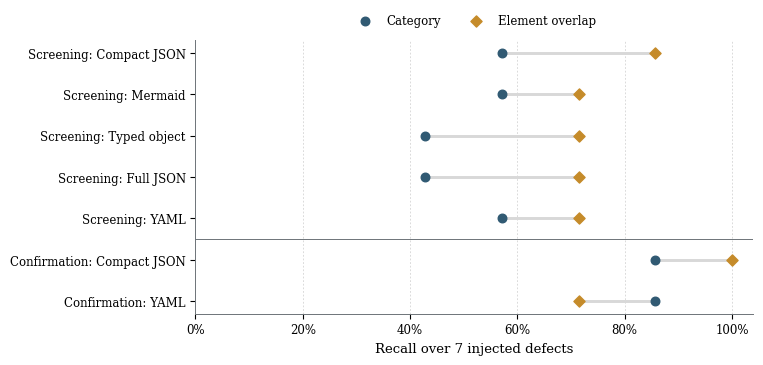

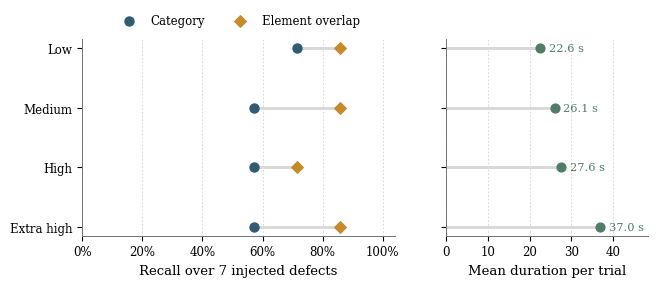

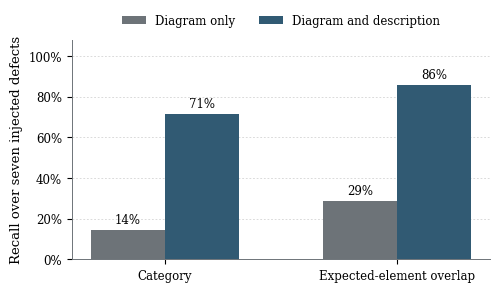

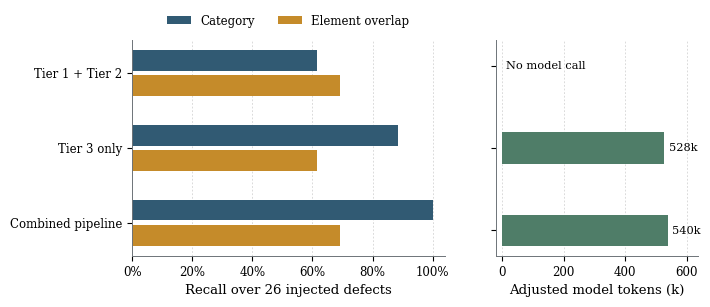

In [4]:
def ir_figure() -> None:
    screening = {g["config"]["ir_format"]: g for g in load("e2-ir-screening/analysis.json")["groups"]}
    confirmation = {g["config"]["ir_format"]: g for g in load("e2-ir-holdout/analysis-finalists.json")["groups"]}
    keys = ["compact_json", "mermaid", "pydantic", "pydantic_json", "yaml"]
    labels = ["Compact JSON", "Mermaid", "Typed object", "Full JSON", "YAML"]
    rows = [("Screening", key, label) for key, label in zip(keys, labels)]
    rows += [("Confirmation", "compact_json", "Compact JSON"), ("Confirmation", "yaml", "YAML")]
    y, category, anchor, row_labels = list(reversed(range(len(rows)))), [], [], []
    for stage, key, label in rows:
        group = screening[key] if stage == "Screening" else confirmation[key]
        cat, anc = group["category_only"]["recall"], group["localization"]["anchor"]["recall"]
        if stage == "Confirmation":
            cat = (group["category_only"]["matched"] - screening[key]["category_only"]["matched"]) / 7
            anc = (group["localization"]["anchor"]["matched"] - screening[key]["localization"]["anchor"]["matched"]) / 7
        category.append(cat); anchor.append(anc); row_labels.append(f"{stage}: {label}")
    fig, axis = plt.subplots(figsize=(7.2, 3.55))
    for yi, cat, anc in zip(y, category, anchor): axis.plot([cat, anc], [yi, yi], color=GRID, linewidth=2.1, zorder=1)
    axis.scatter(category, y, color=NAVY, marker="o", s=38, label="Category", zorder=3)
    axis.scatter(anchor, y, color=OCHRE, marker="D", s=32, label="Element overlap", zorder=3)
    axis.set_yticks(y, row_labels); axis.axhline(1.5, color=SLATE, linewidth=0.7, zorder=0)
    axis.set_xlabel("Recall over 7 injected defects"); percent_axis(axis)
    axis.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
    finish(fig, "evaluation-ir-selection")


def reasoning_figure() -> None:
    groups = {g["config"]["reasoning_effort"]: g for g in load("e3-reasoning-terra/analysis.json")["groups"]}
    keys, labels, y = ["low", "medium", "high", "xhigh"], ["Low", "Medium", "High", "Extra high"], [3, 2, 1, 0]
    category = [groups[key]["category_only"]["recall"] for key in keys]
    anchor = [groups[key]["localization"]["anchor"]["recall"] for key in keys]
    latency = [groups[key]["latency_ms"] / 1000 for key in keys]
    fig, (axis, time_axis) = plt.subplots(1, 2, figsize=(7.3, 2.55), gridspec_kw={"width_ratios": [1.55, 1]})
    for yi, cat, anc in zip(y, category, anchor): axis.plot([cat, anc], [yi, yi], color=GRID, linewidth=2.1, zorder=1)
    axis.scatter(category, y, color=NAVY, marker="o", s=42, label="Category", zorder=3)
    axis.scatter(anchor, y, color=OCHRE, marker="D", s=34, label="Element overlap", zorder=3)
    axis.set_yticks(y, labels); axis.set_xlabel("Recall over 7 injected defects"); percent_axis(axis)
    axis.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
    time_axis.hlines(y, 0, latency, color=GRID, linewidth=2.1, zorder=1); time_axis.scatter(latency, y, color=GREEN, s=40, zorder=3)
    for yi, value in zip(y, latency): time_axis.text(value + 2.0, yi, f"{value:.1f} s", va="center", color=GREEN, fontsize=8.2)
    time_axis.set_yticks(y, []); time_axis.set_xlim(0, max(latency) * 1.31); time_axis.set_xlabel("Mean duration per trial")
    time_axis.grid(axis="x", color=GRID, linewidth=0.65, linestyle=(0, (2, 2))); time_axis.set_axisbelow(True)
    finish(fig, "evaluation-reasoning-effort")


def description_figure() -> None:
    data = load("e4-description/run.json")["headline"]
    diagram = [data["diagram_only"]["category"]["recall"], data["diagram_only"]["anchor"]["recall"]]
    described = [data["description_present"]["category"]["recall"], data["description_present"]["anchor"]["recall"]]
    x, width = [0, 1], 0.32
    fig, axis = plt.subplots(figsize=(5.4, 2.85))
    bars_a = axis.bar([value - width / 2 for value in x], diagram, width, color=SLATE, label="Diagram only")
    bars_b = axis.bar([value + width / 2 for value in x], described, width, color=NAVY, label="Diagram and description")
    axis.bar_label(bars_a, labels=[f"{value:.0%}" for value in diagram], padding=3, fontsize=8.5)
    axis.bar_label(bars_b, labels=[f"{value:.0%}" for value in described], padding=3, fontsize=8.5)
    axis.set_xticks(x, ["Category", "Expected-element overlap"]); axis.set_ylabel("Recall over seven injected defects")
    axis.set_ylim(0, 1.08); axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    axis.grid(axis="y", color=GRID, linewidth=0.65, linestyle=(0, (2, 2))); axis.set_axisbelow(True)
    axis.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), frameon=False, ncol=2)
    finish(fig, "evaluation-reference-description")


def validator_figure() -> None:
    data = load("e5-validator-combined/analysis.json")["combined"]
    keys, labels, y = ["deterministic", "llm_only", "full"], ["Tier 1 + Tier 2", "Tier 3 only", "Combined pipeline"], [2, 1, 0]
    category = [data[key]["target_category"]["recall"] for key in keys]
    anchor = [data[key]["target_anchor"]["recall"] for key in keys]
    tokens = [data[key]["usage"]["total_tokens"] / 1000 for key in keys]
    fig, (axis, cost_axis) = plt.subplots(1, 2, figsize=(7.3, 2.8), gridspec_kw={"width_ratios": [1.55, 1]})
    axis.barh([value + 0.17 for value in y], category, height=0.28, color=NAVY, label="Category")
    axis.barh([value - 0.17 for value in y], anchor, height=0.28, color=OCHRE, label="Element overlap")
    axis.set_yticks(y, labels); axis.set_xlabel("Recall over 26 injected defects"); percent_axis(axis)
    axis.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
    bars = cost_axis.barh(y, tokens, color=GREEN, height=0.38)
    cost_axis.bar_label(bars, labels=["No model call" if value == 0 else f"{value:.0f}k" for value in tokens], padding=3, fontsize=8.2)
    cost_axis.set_yticks(y, []); cost_axis.set_xlim(-20, max(tokens) * 1.18); cost_axis.set_xlabel("Adjusted model tokens (k)")
    cost_axis.grid(axis="x", color=GRID, linewidth=0.65, linestyle=(0, (2, 2))); cost_axis.set_axisbelow(True)
    finish(fig, "evaluation-validator-comparison")


ir_figure(); reasoning_figure(); description_figure(); validator_figure()


## Final evaluation

E6 reports detection by defect class. E7 and E8 summarize repair and refinement outcomes.

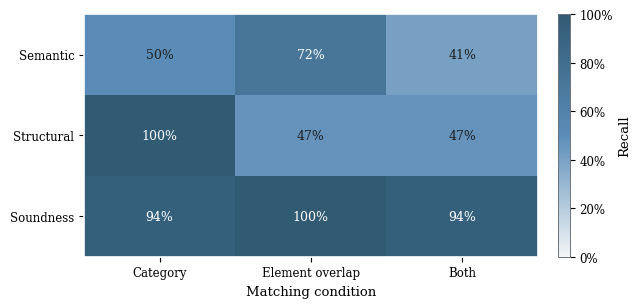

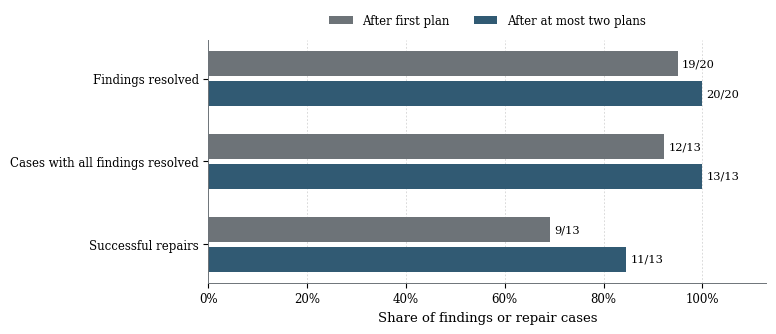

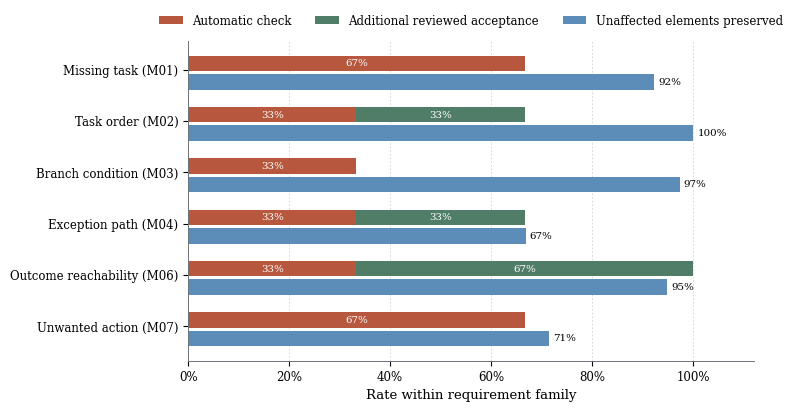

Saved 7 thesis figures to /home/mjurzak/master_thesis/thesis/figures/ch06


In [5]:
def detection_figure() -> None:
    data = load("e6-detection/analysis-detection.json")["by_class"]
    keys, labels = ["SEM", "STRUCT", "SOUND"], ["Semantic", "Structural", "Soundness"]
    values = [[data[key]["target_category"]["recall"], data[key]["target_anchor"]["recall"], data[key]["target_category_and_anchor"]["recall"]] for key in keys]
    cmap = LinearSegmentedColormap.from_list("academic_blue", ["#F3F5F6", BLUE, NAVY])
    fig, axis = plt.subplots(figsize=(6.4, 3.15)); image = axis.imshow(values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    axis.set_yticks(range(3), labels); axis.set_xticks(range(3), ["Category", "Element overlap", "Both"]); axis.set_xlabel("Matching condition")
    for row, row_values in enumerate(values):
        for column, value in enumerate(row_values):
            axis.text(column, row, f"{value:.0%}", ha="center", va="center", color="white" if value >= 0.67 else "#202020", fontsize=9)
    colorbar = fig.colorbar(image, ax=axis, fraction=0.045, pad=0.04)
    colorbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0)); colorbar.set_label("Recall")
    for spine in axis.spines.values(): spine.set_visible(True); spine.set_color("white"); spine.set_linewidth(1.2)
    finish(fig, "evaluation-detection-by-class")


def repair_figure() -> None:
    data = load("e7-repair/analysis.json")["overall"]
    initial = [data["first_resolved"] / data["targets"], data["first_complete_cases"] / data["cases"], data["first_safe_target_success_cases"] / data["cases"]]
    bounded = [data["final_resolved"] / data["targets"], data["final_complete_cases"] / data["cases"], data["final_safe_target_success_cases"] / data["cases"]]
    initial_counts = [(data["first_resolved"], data["targets"]), (data["first_complete_cases"], data["cases"]), (data["first_safe_target_success_cases"], data["cases"])]
    bounded_counts = [(data["final_resolved"], data["targets"]), (data["final_complete_cases"], data["cases"]), (data["final_safe_target_success_cases"], data["cases"])]
    y = [2, 1, 0]; fig, axis = plt.subplots(figsize=(7.2, 3.15))
    bars_a = axis.barh([value + 0.18 for value in y], initial, height=0.3, color=SLATE, label="After first plan")
    bars_b = axis.barh([value - 0.18 for value in y], bounded, height=0.3, color=NAVY, label="After at most two plans")
    axis.bar_label(bars_a, labels=[f"{a}/{b}" for a, b in initial_counts], padding=3, fontsize=8.2)
    axis.bar_label(bars_b, labels=[f"{a}/{b}" for a, b in bounded_counts], padding=3, fontsize=8.2)
    axis.set_yticks(y, ["Findings resolved", "Cases with all findings resolved", "Successful repairs"])
    axis.set_xlabel("Share of findings or repair cases"); percent_axis(axis); axis.set_xlim(0, 1.13)
    axis.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2)
    finish(fig, "evaluation-repair-outcomes")


def refinement_figure() -> None:
    data = load("e8-refinement/analysis.json")["by_operator"]
    manual = load("e8-refinement/manual-review.json")["cases"]
    keys = ["M01", "M02", "M03", "M04", "M06", "M07"]
    labels = ["Missing task (M01)", "Task order (M02)", "Branch condition (M03)", "Exception path (M04)", "Outcome reachability (M06)", "Unwanted action (M07)"]
    y = list(reversed(range(len(keys))))
    success = [data[key]["requirement_satisfaction_rate"] for key in keys]
    accepted = Counter(case["case_id"].split("-")[0] for case in manual if case["adjudication"] in {"alternative_valid", "alternative_valid_formal_inconclusive"})
    reviewed = [min(1.0, value + accepted[key] / data[key]["records"]) for key, value in zip(keys, success)]
    addition = [reviewed_value - automatic for reviewed_value, automatic in zip(reviewed, success)]
    preservation = [data[key]["mean_preservation_rate"] for key in keys]
    fig, axis = plt.subplots(figsize=(7.3, 4.15))
    automatic_bars = axis.barh([value + 0.12 for value in y], success, height=0.3, color=VERMILION, label="Automatic check")
    reviewed_bars = axis.barh([value + 0.12 for value in y], addition, left=success, height=0.3, color=GREEN, label="Additional reviewed acceptance")
    preservation_bars = axis.barh([value - 0.24 for value in y], preservation, height=0.3, color=BLUE, label="Unaffected elements preserved")
    axis.bar_label(automatic_bars, labels=[f"{value:.0%}" if value else "" for value in success], label_type="center", color="white", fontsize=7.4)
    axis.bar_label(reviewed_bars, labels=[f"{value:.0%}" if value else "" for value in addition], label_type="center", color="white", fontsize=7.4)
    axis.bar_label(preservation_bars, labels=[f"{value:.0%}" for value in preservation], padding=3, fontsize=7.4)
    axis.set_yticks(y, labels); axis.set_xlabel("Rate within requirement family"); percent_axis(axis); axis.set_xlim(0, 1.12)
    axis.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3)
    finish(fig, "evaluation-refinement")


detection_figure(); repair_figure(); refinement_figure()
print(f"Saved 7 thesis figures to {FIGURES}")


## Repeatability diagnostic

E9 compares three observations of each selected case. It is descriptive because the provider exposes no deterministic seed and the CLI version changed after E6.

In [6]:
e9 = A["E9"]
display(pd.Series({
    "Cases": e9["design"]["cases"],
    "Observations": e9["design"]["cases"] * e9["design"]["runs_per_case"],
    "Controls with alerts": e9["controls"]["alerted_observations"],
    "Control observations": e9["controls"]["observations"],
    "Mean category Jaccard": e9["category_stability_summary"]["all_semantic_findings"]["mean_case_pairwise_multiset_jaccard"],
    "Mean element Jaccard": e9["indicated_element_stability_summary"]["all_semantic_findings"]["mean_case_pairwise_jaccard"],
}, name="E9"))


Cases                    10.000000
Observations             30.000000
Controls with alerts      7.000000
Control observations      9.000000
Mean category Jaccard     0.653175
Mean element Jaccard      0.699670
Name: E9, dtype: float64